<a href="https://colab.research.google.com/github/vyshnavps07-oss/Disaster-Risk-Classification-Using-Apache-Spark-ML/blob/main/disaster_risk_classification_using_apache_spark_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Disaster Risk Classification Using Apache Spark MLlib

## A Machine Learning Approach Based on the World Risk Index Dataset

### Author
**Vyshnav P S**

---

### Project Overview

This project develops a multiclass disaster risk classification model using the World Risk Index (WRI) dataset and Apache Spark MLlib. Four disaster risk indicators—Exposure, Susceptibility, Coping Capacity, and Adaptive Capacity—are used to classify countries into four disaster risk levels: Low, Medium, High, and Very High.

The project evaluates Logistic Regression, Decision Tree, and Random Forest classifiers to identify the most effective model for disaster risk prediction. The workflow includes data preparation, exploratory data analysis, feature engineering, model training, evaluation, and interpretation.

---

**Tools & Technologies**

- Python
- Apache Spark MLlib
- Google Colab
- Pandas
- Matplotlib
- Seaborn

---

In [ ]:
# ==========================================================
# Install Required Packages (Only if Missing)
# ==========================================================

try:
    import pyspark
    import findspark
    print("✅ Required packages already installed.")
except ImportError:
    print("Installing required packages...")
    !pip -q install pyspark findspark

✅ Required packages already installed.


In [ ]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Core libraries
import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Spark
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when

# Spark ML
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StringIndexer

from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier
)

from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator
)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [ ]:
# ==========================================================
# Visualization Theme
# ==========================================================

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams.update({

    "figure.figsize": (10,6),
    "figure.dpi": 120,
    "savefig.dpi": 300,

    "font.family": "DejaVu Sans",

    "axes.titlesize": 16,
    "axes.titleweight": "bold",

    "axes.labelsize": 13,
    "axes.labelweight": "bold",

    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    "legend.fontsize": 11,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "grid.alpha": 0.25

})

print("✅ Visualization theme configured.")

✅ Visualization theme configured.


In [ ]:
# ==========================================================
# Mount Google Drive
# ==========================================================

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================================
# Create Spark Session
# ==========================================================

spark = (
    SparkSession.builder
    .appName("Disaster Risk Classification")
    .master("local[*]")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("✅ Spark Session Created")
print(f"Spark Version : {spark.version}")

✅ Spark Session Created
Spark Version : 4.0.3


In [ ]:
# ==========================================================
# Load Dataset
# ==========================================================

DATA_PATH = "/content/drive/MyDrive/Disaster_Risk_Classification/data/world_risk_index.csv"

df_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

print("✅ Dataset Loaded Successfully")

✅ Dataset Loaded Successfully


In [ ]:
# ==========================================================
# Dataset Verification & Standardize Column Names
# ==========================================================

from pyspark.sql.functions import col

# Standardize column names
for column in df_raw.columns:
    new_column = (
        column.strip()          # Remove leading/trailing spaces
              .replace(".", "_")
              .replace(" ", "_")
              .replace("-", "_")
              .replace("(", "")
              .replace(")", "")
    )

    df_raw = df_raw.withColumnRenamed(column, new_column)

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print(f"Records : {df_raw.count():,}")
print(f"Columns : {len(df_raw.columns)}")

print("\nFirst 10 Records")

display(
    df_raw.select(
        "WRI_Country",
        "ISO3_Code",
        "Year",
        "W",
        "E",
        "V",
        "C",
        "A"
    ).limit(10)
)

DATASET SUMMARY
Records : 5,018
Columns : 248

First 10 Records


DataFrame[WRI_Country: string, ISO3_Code: string, Year: int, W: double, E: double, V: double, C: double, A: double]

In [ ]:
# ==========================================================
# Data Preparation
# Create Clean Working Dataset
# ==========================================================

from pyspark.sql.functions import col, when

# ----------------------------------------------------------
# Select Required Variables and Rename Columns
# ----------------------------------------------------------

df = (
    df_raw.select(

        col("WRI_Country").alias("country"),

        col("ISO3_Code").alias("iso3"),

        col("Year").alias("year"),

        col("W").alias("wri_score"),

        col("E").alias("exposure"),

        col("V").alias("susceptibility"),

        col("C").alias("coping_capacity"),

        col("A").alias("adaptive_capacity")

    )
)

# ----------------------------------------------------------
# Create Disaster Risk Categories
# ----------------------------------------------------------

df = (
    df.withColumn(
        "risk_category",
        when(col("wri_score") < 2.5, "Low")
        .when(col("wri_score") < 5.0, "Medium")
        .when(col("wri_score") < 10.0, "High")
        .otherwise("Very High")
    )
)

# ----------------------------------------------------------
# Display Dataset Summary
# ----------------------------------------------------------

print("=" * 60)
print("WORKING DATASET CREATED")
print("=" * 60)

print(f"Total Records : {df.count():,}")
print(f"Total Columns : {len(df.columns)}")

print("\nColumns")

for c in df.columns:
    print(f"• {c}")

print("\nRisk Category Distribution")

df.groupBy("risk_category").count().orderBy("risk_category").show()

display(df.limit(10))

WORKING DATASET CREATED
Total Records : 5,018
Total Columns : 9

Columns
• country
• iso3
• year
• wri_score
• exposure
• susceptibility
• coping_capacity
• adaptive_capacity
• risk_category

Risk Category Distribution
+-------------+-----+
|risk_category|count|
+-------------+-----+
|         High|  843|
|          Low| 1471|
|       Medium| 1333|
|    Very High| 1371|
+-------------+-----+



DataFrame[country: string, iso3: string, year: int, wri_score: double, exposure: double, susceptibility: double, coping_capacity: double, adaptive_capacity: double, risk_category: string]

In [ ]:
# ==========================================================
# Data Quality Validation
# ==========================================================

from pyspark.sql.functions import col, count, when

print("=" * 60)
print("DATA QUALITY VALIDATION")
print("=" * 60)

# ----------------------------------------------------------
# Missing Values
# ----------------------------------------------------------

missing = df.select([
    count(
        when(col(c).isNull(), c)
    ).alias(c)
    for c in df.columns
])

print("\nMissing Values")

missing.show(truncate=False)

# ----------------------------------------------------------
# Duplicate Records
# ----------------------------------------------------------

duplicate_count = df.count() - df.dropDuplicates().count()

print(f"\nDuplicate Records : {duplicate_count}")

# ----------------------------------------------------------
# Data Types
# ----------------------------------------------------------

print("\nData Types")

df.printSchema()

# ----------------------------------------------------------
# Summary Statistics
# ----------------------------------------------------------

display(
    df.describe(
        "wri_score",
        "exposure",
        "susceptibility",
        "coping_capacity",
        "adaptive_capacity"
    )
)

DATA QUALITY VALIDATION

Missing Values
+-------+----+----+---------+--------+--------------+---------------+-----------------+-------------+
|country|iso3|year|wri_score|exposure|susceptibility|coping_capacity|adaptive_capacity|risk_category|
+-------+----+----+---------+--------+--------------+---------------+-----------------+-------------+
|0      |0   |0   |0        |0       |0             |0              |0                |0            |
+-------+----+----+---------+--------+--------------+---------------+-----------------+-------------+


Duplicate Records : 0

Data Types
root
 |-- country: string (nullable = true)
 |-- iso3: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- wri_score: double (nullable = true)
 |-- exposure: double (nullable = true)
 |-- susceptibility: double (nullable = true)
 |-- coping_capacity: double (nullable = true)
 |-- adaptive_capacity: double (nullable = true)
 |-- risk_category: string (nullable = false)



DataFrame[summary: string, wri_score: string, exposure: string, susceptibility: string, coping_capacity: string, adaptive_capacity: string]

In [ ]:
# ==========================================================
# Project Paths
# ==========================================================

import os

PROJECT_PATH = "/content/drive/MyDrive/Disaster_Risk_Classification"

IMAGE_PATH = os.path.join(PROJECT_PATH, "images")

os.makedirs(IMAGE_PATH, exist_ok=True)

print("Image Folder :", IMAGE_PATH)

Image Folder : /content/drive/MyDrive/Disaster_Risk_Classification/images


##  Exploratory Data Analysis

The exploratory data analysis investigates the characteristics of the disaster risk dataset and provides insights into the distribution and relationships of the selected disaster risk indicators.

---

## Figure 1. Distribution of Disaster Risk Categories

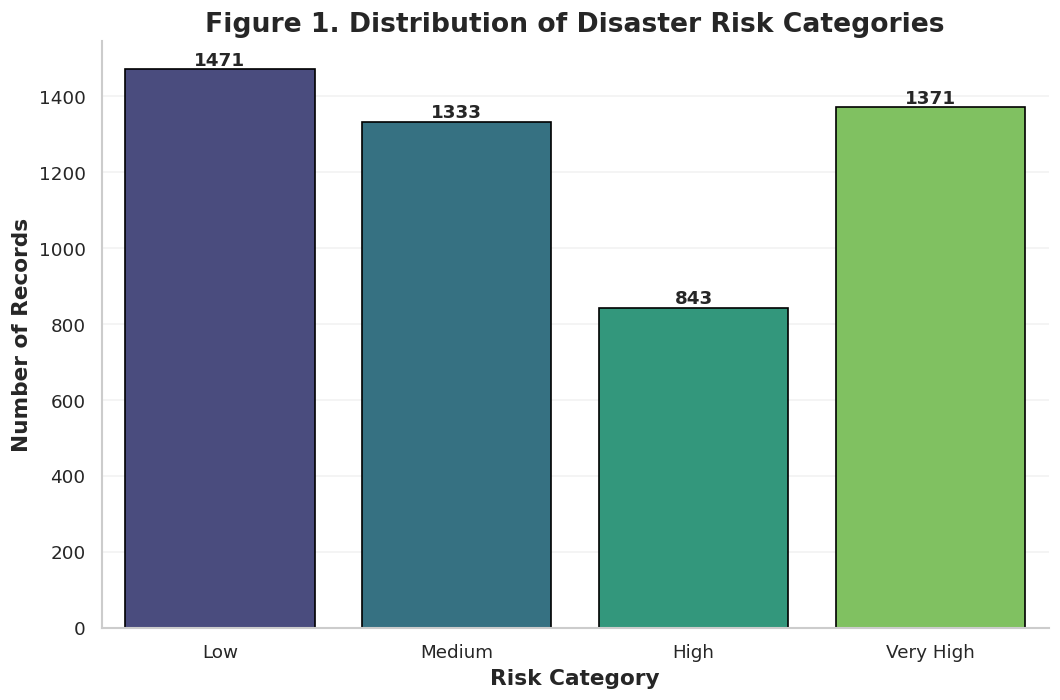

In [ ]:
# ==========================================================
# Figure 1
# Distribution of Disaster Risk Categories
# ==========================================================

# Convert Spark DataFrame to Pandas (Only Once)
pdf = df.toPandas()

order = ["Low", "Medium", "High", "Very High"]

plt.figure(figsize=(9,6))

ax = sns.countplot(
    data=pdf,
    x="risk_category",
    order=order,
    palette="viridis",
    edgecolor="black",
    linewidth=1
)

# Add labels
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Figure 1. Distribution of Disaster Risk Categories",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Risk Category")

plt.ylabel("Number of Records")

plt.tight_layout()

# Save Figure
plt.savefig(
    os.path.join(
        IMAGE_PATH,
        "fig01_risk_category_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insights

- The dataset consists of four disaster risk categories.
- The **Low** and **Very High** categories contain the largest number of observations.
- Although the dataset is not perfectly balanced, each class contains sufficient observations for multiclass machine learning.
- The observed distribution provides an appropriate basis for evaluating classification models.

## Figure 2. Distribution of Disaster Risk Indicators

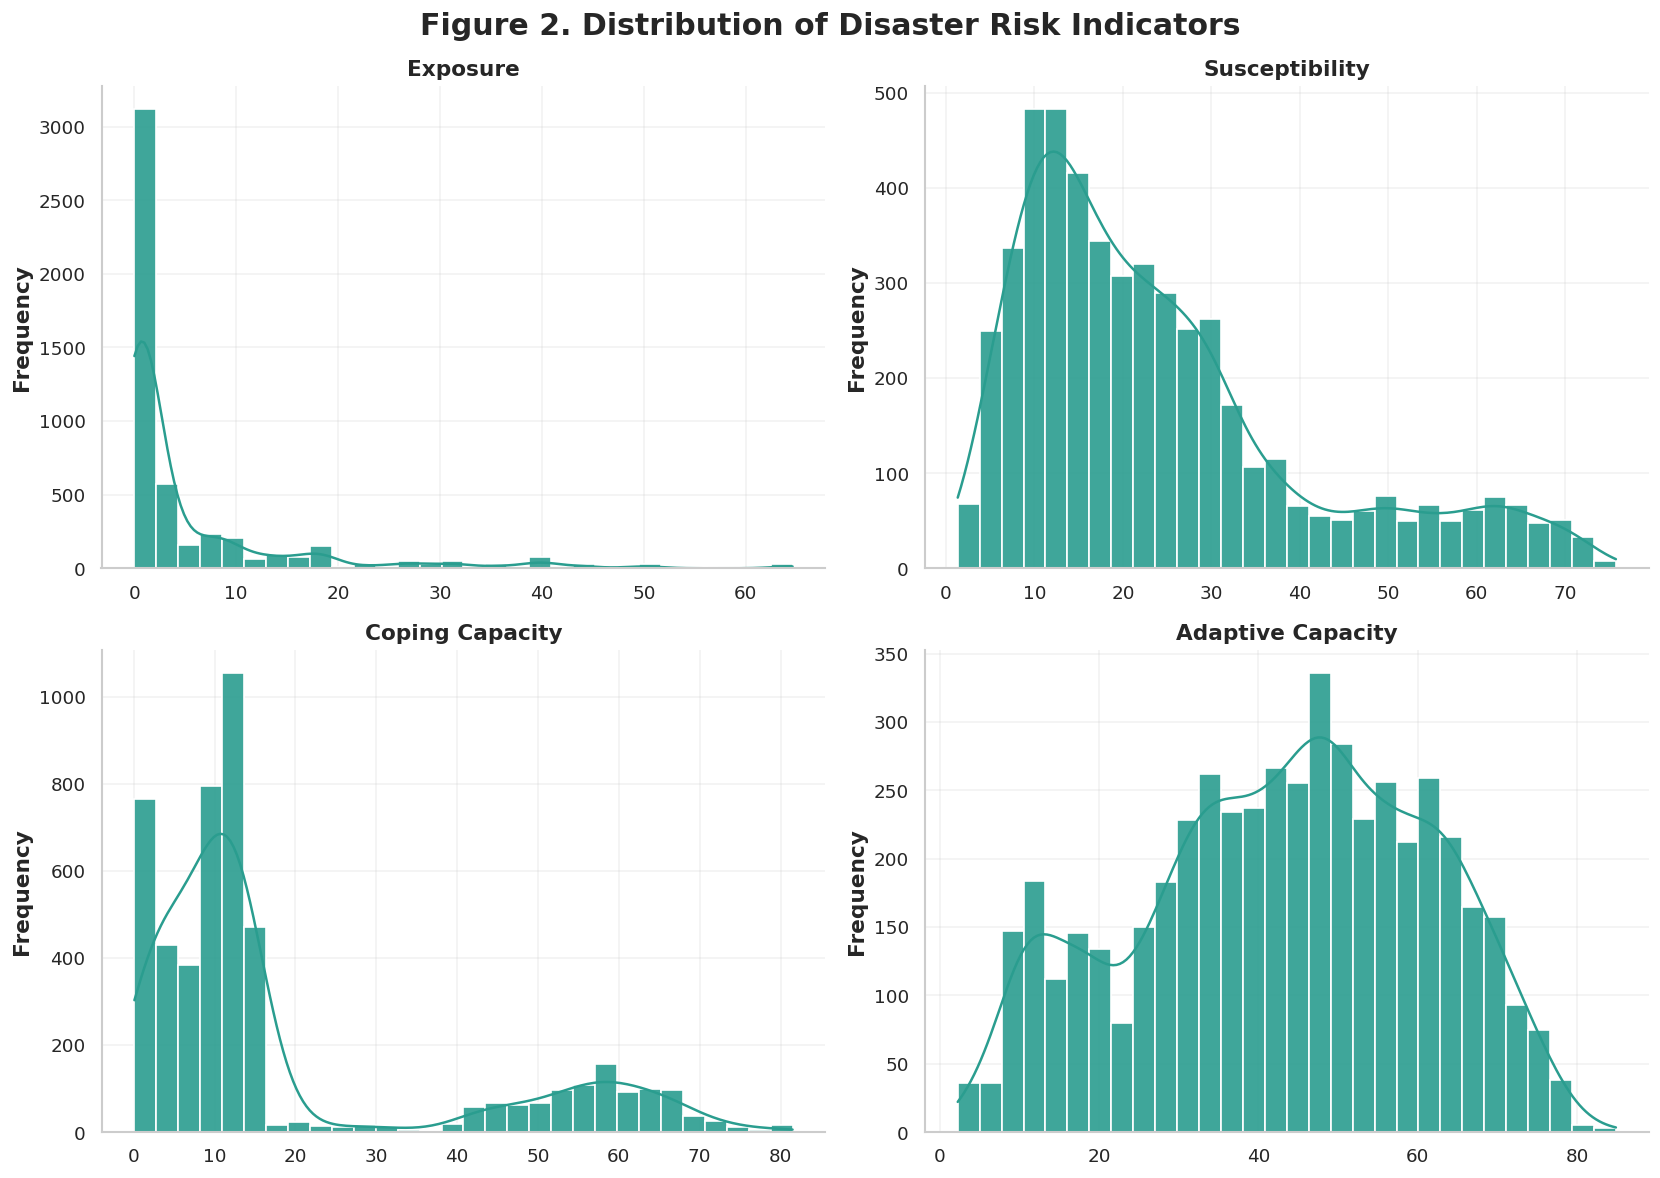

In [ ]:
# ==========================================================
# Figure 2
# Distribution of Disaster Risk Indicators
# ==========================================================

features = [

    ("exposure","Exposure"),

    ("susceptibility","Susceptibility"),

    ("coping_capacity","Coping Capacity"),

    ("adaptive_capacity","Adaptive Capacity")

]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

for ax,(feature,title) in zip(
    axes.flatten(),
    features
):

    sns.histplot(
        pdf[feature],
        bins=30,
        kde=True,
        color="#2A9D8F",
        edgecolor="white",
        alpha=0.9,
        ax=ax
    )

    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

fig.suptitle(
    "Figure 2. Distribution of Disaster Risk Indicators",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_PATH,
        "fig02_feature_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insights

- Exposure values are concentrated at lower levels with a gradual decline toward higher values.
- Susceptibility exhibits moderate variability across countries.
- Coping Capacity and Adaptive Capacity display broader distributions, indicating differences in resilience among countries.
- The variation observed across the four indicators supports their use as predictive features for disaster risk classification.

## Figure 3. Correlation Between Disaster Risk Indicators

This figure illustrates the linear relationship among the selected disaster risk indicators and the World Risk Index (WRI) score using Pearson's correlation coefficient.

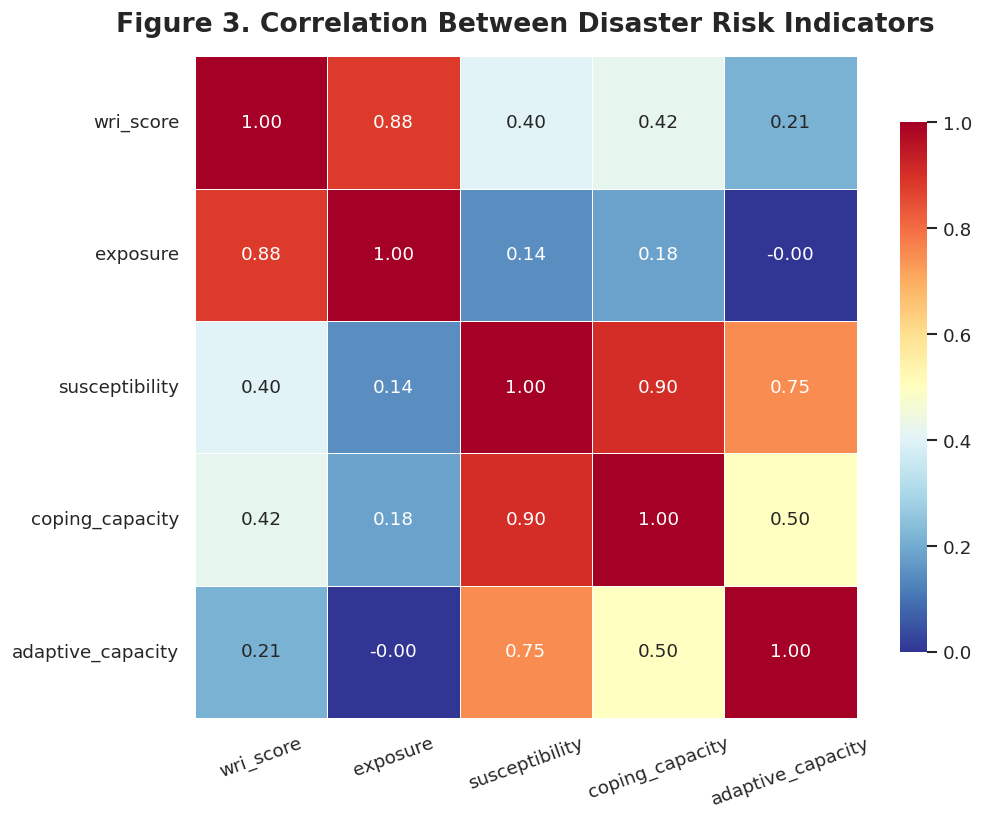

In [ ]:
# ==========================================================
# Figure 3
# Correlation Heatmap
# ==========================================================

# Select numerical variables
corr = pdf[
    [
        "wri_score",
        "exposure",
        "susceptibility",
        "coping_capacity",
        "adaptive_capacity"
    ]
].corr(method="pearson")

plt.figure(figsize=(9,7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8},
    annot_kws={"size":11}
)

plt.title(
    "Figure 3. Correlation Between Disaster Risk Indicators",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=20)
plt.yticks(rotation=0)

plt.tight_layout()

# Save Figure
plt.savefig(
    os.path.join(
        IMAGE_PATH,
        "fig03_correlation_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insights

- Exposure demonstrates the strongest positive relationship with the World Risk Index score.
- Susceptibility also shows a positive association with disaster risk.
- Coping Capacity and Adaptive Capacity exhibit different correlation patterns, highlighting their complementary roles in disaster resilience.
- The absence of extremely high inter-feature correlations suggests limited multicollinearity, making the selected variables suitable for machine learning.

## Figure 4. Distribution of Disaster Risk Indicators Across Risk Categories

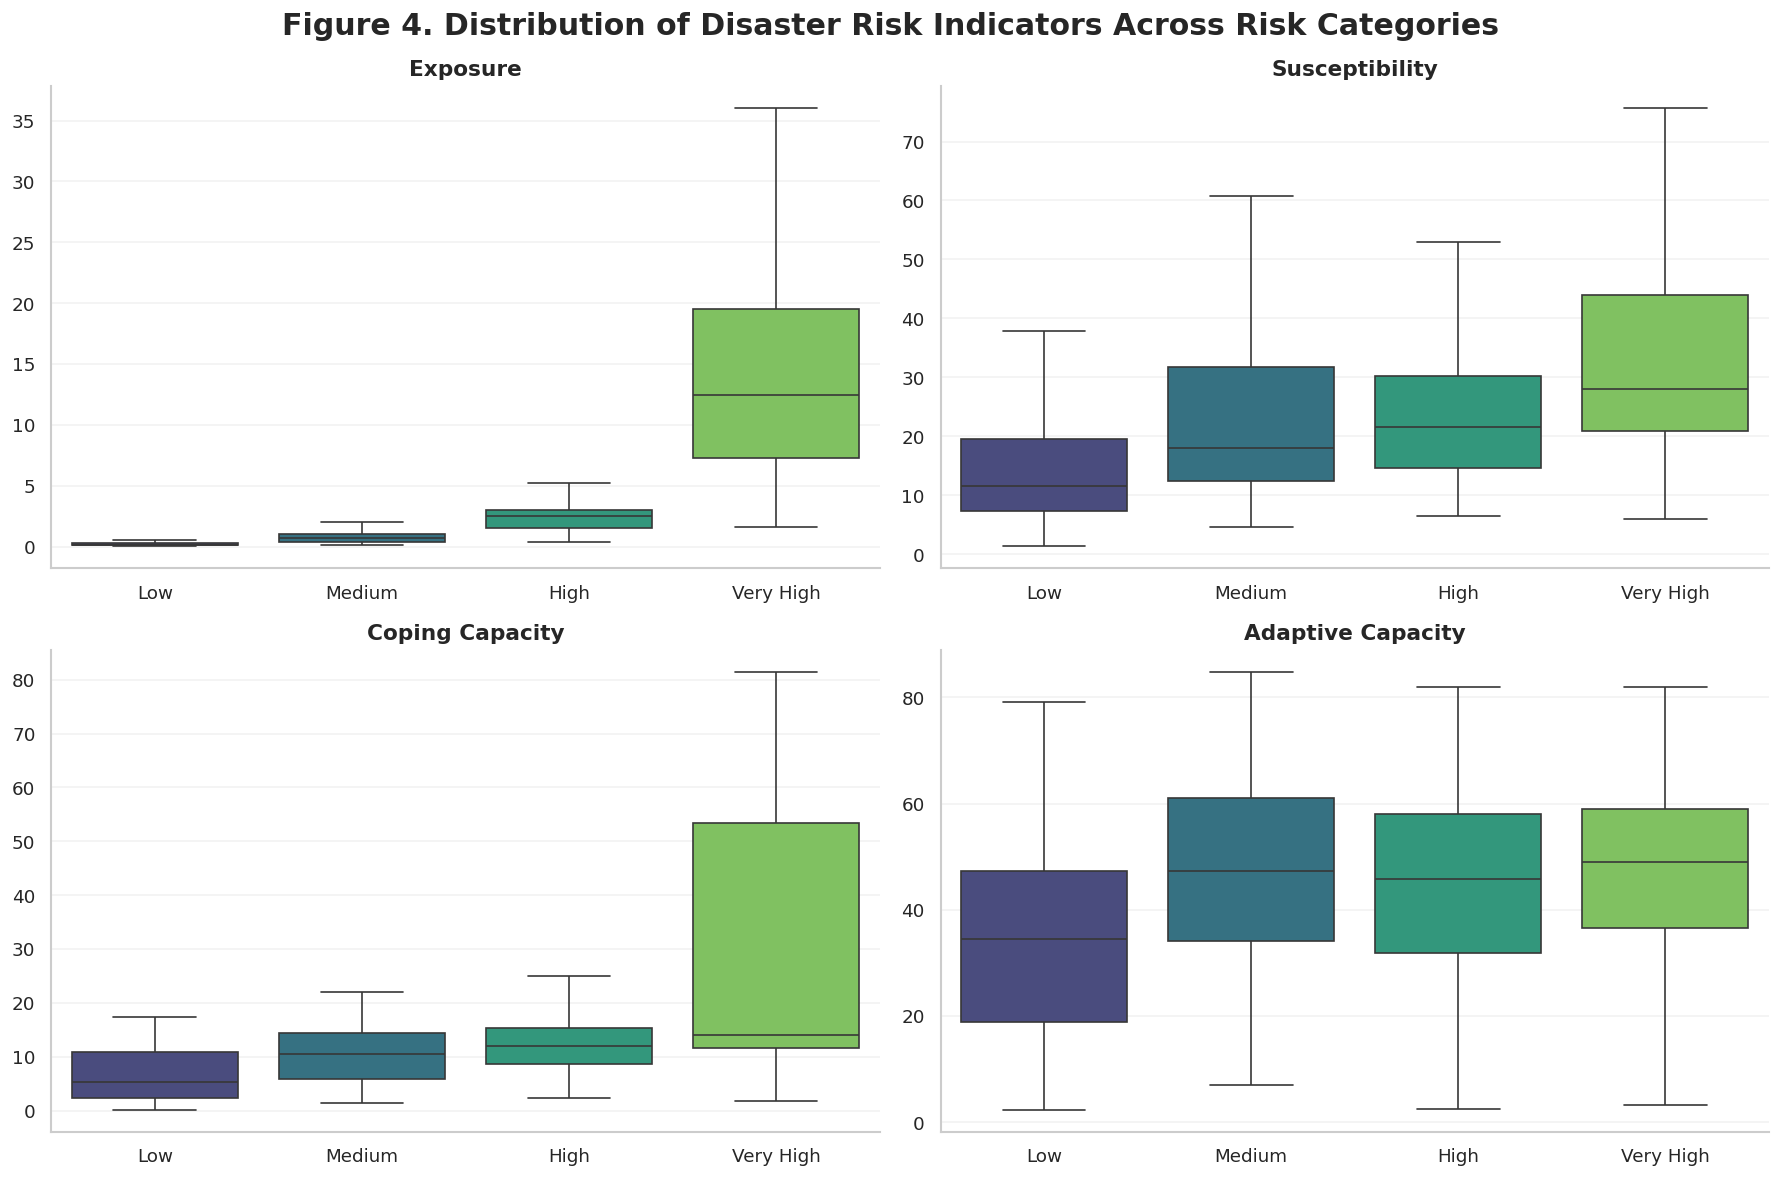

In [ ]:
# ==========================================================
# Figure 4
# Feature Comparison by Risk Category
# ==========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15,10)
)

order = [
    "Low",
    "Medium",
    "High",
    "Very High"
]

plots = [

    ("exposure","Exposure"),

    ("susceptibility","Susceptibility"),

    ("coping_capacity","Coping Capacity"),

    ("adaptive_capacity","Adaptive Capacity")

]

for ax, (feature, title) in zip(
    axes.flatten(),
    plots
):

    sns.boxplot(
        data=pdf,
        x="risk_category",
        y=feature,
        order=order,
        palette="viridis",
        linewidth=1,
        showfliers=False,
        ax=ax
    )

    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle(
    "Figure 4. Distribution of Disaster Risk Indicators Across Risk Categories",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_PATH,
        "fig04_boxplots.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insights

- Higher disaster risk categories generally exhibit greater exposure levels.
- The distributions of coping capacity and adaptive capacity vary across risk categories, indicating differences in resilience.
- Several indicators show clear separation between lower and higher risk groups, supporting their predictive value in the classification models.

## Figure 5. Relationship Between Exposure and the World Risk Index

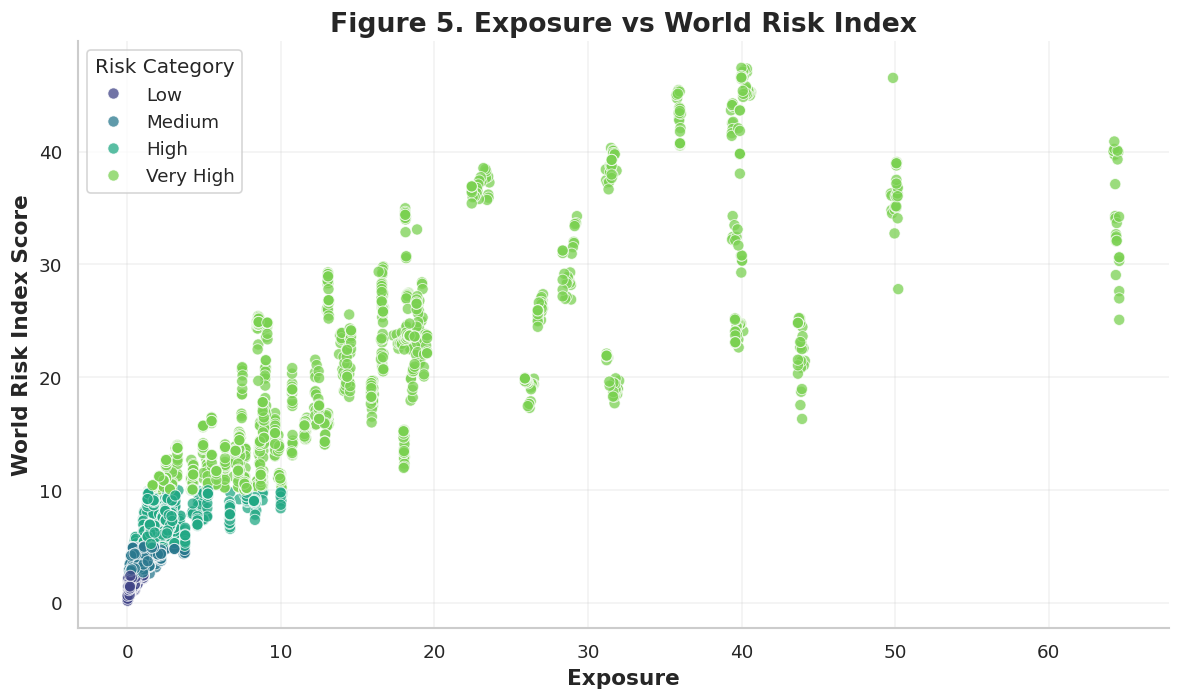

In [ ]:
# ==========================================================
# Figure 5
# Exposure vs World Risk Index
# ==========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pdf,
    x="exposure",
    y="wri_score",
    hue="risk_category",
    hue_order=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    palette="viridis",
    alpha=0.75,
    s=45
)

plt.title(
    "Figure 5. Exposure vs World Risk Index",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Exposure")

plt.ylabel("World Risk Index Score")

plt.legend(title="Risk Category")

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_PATH,
        "fig05_exposure_vs_wri.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Insights

- Countries with higher exposure generally exhibit higher World Risk Index scores.
- The scatter plot reveals a positive association between exposure and overall disaster risk.
- Although overlap exists among categories, the general trend supports the importance of exposure as a key predictor.

#  Feature Engineering

Machine learning algorithms in Apache Spark require predictor variables to be assembled into a single feature vector and the target variable to be encoded as a numeric label.

This section prepares the dataset for model training using Spark ML's `VectorAssembler` and `StringIndexer`.

In [ ]:
# ==========================================================
# Assemble Feature Vector
# ==========================================================

from pyspark.ml.feature import VectorAssembler

feature_columns = [
    "exposure",
    "susceptibility",
    "coping_capacity",
    "adaptive_capacity"
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

df_features = assembler.transform(df)

print("✅ Feature vector created successfully.")

✅ Feature vector created successfully.


In [ ]:
# ==========================================================
# Encode Target Variable (Custom Label Mapping)
# ==========================================================

from pyspark.sql.functions import when, col

df_ml = df_features.withColumn(
    "label",
    when(col("risk_category") == "Low", 0)
    .when(col("risk_category") == "Medium", 1)
    .when(col("risk_category") == "High", 2)
    .when(col("risk_category") == "Very High", 3)
    .cast("double")
)

print("✅ Target variable encoded successfully.")

✅ Target variable encoded successfully.


In [ ]:
# ==========================================================
# Verify Machine Learning Dataset
# ==========================================================

df_ml.select(
    "features",
    "risk_category",
    "label"
).show(10, truncate=False)

+-------------------------+-------------+-----+
|features                 |risk_category|label|
+-------------------------+-------------+-----+
|[0.25,69.83,73.22,75.05] |Medium       |1.0  |
|[2.38,21.96,44.37,10.57] |High         |2.0  |
|[2.65,39.85,52.73,40.58] |Very High    |3.0  |
|[0.02,4.32,2.15,13.18]   |Low          |0.0  |
|[2.18,55.35,62.14,77.32] |Very High    |3.0  |
|[1.21,15.78,9.83,28.97]  |Medium       |1.0  |
|[11.67,21.04,10.67,39.49]|Very High    |3.0  |
|[0.24,22.96,11.21,41.54] |Low          |0.0  |
|[32.03,12.09,7.7,19.71]  |Very High    |3.0  |
|[0.17,11.3,6.4,32.84]    |Low          |0.0  |
+-------------------------+-------------+-----+
only showing top 10 rows


In [ ]:
# ==========================================================
# Label Mapping
# ==========================================================

print("=" * 50)
print("Label Mapping")
print("=" * 50)

label_mapping = {
    0: "Low",
    1: "Medium",
    2: "High",
    3: "Very High"
}

for key, value in label_mapping.items():
    print(f"{key} → {value}")

Label Mapping
0 → Low
1 → Medium
2 → High
3 → Very High


In [ ]:
# ==========================================================
# Model Evaluation Function
# ==========================================================

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

def evaluate_model(predictions):

    accuracy = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="accuracy"
    ).evaluate(predictions)

    precision = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="weightedPrecision"
    ).evaluate(predictions)

    recall = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="weightedRecall"
    ).evaluate(predictions)

    f1 = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="f1"
    ).evaluate(predictions)

    return accuracy, precision, recall, f1

print("✅ Evaluation function created.")

✅ Evaluation function created.


In [ ]:
# ==========================================================
# Train-Test Split
# ==========================================================

train_df, test_df = df_ml.randomSplit(
    [0.80, 0.20],
    seed=42
)

print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print(f"Training Records : {train_df.count():,}")
print(f"Testing Records  : {test_df.count():,}")
print(f"Total Records    : {train_df.count() + test_df.count():,}")

TRAIN-TEST SPLIT
Training Records : 4,078
Testing Records  : 940
Total Records    : 5,018


In [ ]:
# ==========================================================
# Logistic Regression
# ==========================================================

from pyspark.ml.classification import LogisticRegression

# Train Model
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100
)

lr_model = lr.fit(train_df)

# Predict
lr_predictions = lr_model.transform(test_df)

# Evaluate
lr_accuracy, lr_precision, lr_recall, lr_f1 = evaluate_model(
    lr_predictions
)

# Print Results
print("="*60)
print("LOGISTIC REGRESSION PERFORMANCE")
print("="*60)

print(f"Accuracy            : {lr_accuracy:.4f}")
print(f"Precision (Weighted): {lr_precision:.4f}")
print(f"Recall (Weighted)   : {lr_recall:.4f}")
print(f"F1 Score            : {lr_f1:.4f}")

LOGISTIC REGRESSION PERFORMANCE
Accuracy            : 0.8596
Precision (Weighted): 0.8603
Recall (Weighted)   : 0.8596
F1 Score            : 0.8598


In [ ]:
# ==========================================================
# Logistic Regression Predictions
# ==========================================================

lr_predictions.select(
    "country",
    "risk_category",
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-----------+-------------+-----+----------+------------------------------------------------------------------------------------+
|country    |risk_category|label|prediction|probability                                                                         |
+-----------+-------------+-----+----------+------------------------------------------------------------------------------------+
|Afghanistan|Medium       |1.0  |1.0       |[0.003689620132203437,0.6243778218205398,0.22489836154195086,0.14703419650530597]   |
|Afghanistan|Medium       |1.0  |1.0       |[0.008083118879530053,0.7529826369767154,0.17375810292738442,0.06517614121637003]   |
|Afghanistan|Medium       |1.0  |1.0       |[0.004516447828022657,0.6634909984267617,0.19038178335720446,0.1416107703880112]    |
|Afghanistan|Medium       |1.0  |1.0       |[0.011763357283482353,0.8035915668369188,0.1417680595780834,0.04287701630151564]    |
|Afghanistan|Medium       |1.0  |1.0       |[0.01828396490798853,0.8444002402206257,0.1147

In [ ]:
# ==========================================================
# Store Logistic Regression Results
# ==========================================================

results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1 Score": lr_f1
})

print("✅ Logistic Regression results stored.")

✅ Logistic Regression results stored.


In [ ]:
# ==========================================================
# Project Configuration
# ==========================================================

# Random seed for reproducibility
RANDOM_SEED = 42

# Train-Test Split Ratio
TRAIN_RATIO = 0.80
TEST_RATIO = 0.20

print("✅ Project configuration loaded successfully.")

✅ Project configuration loaded successfully.


In [ ]:
# ==========================================================
# Decision Tree Classification
# ==========================================================

from pyspark.ml.classification import DecisionTreeClassifier

# Create Decision Tree Model
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    maxDepth=10,
    seed=42
)

# Train Model
dt_model = dt.fit(train_df)

# Make Predictions
dt_predictions = dt_model.transform(test_df)

# Evaluate Model
dt_accuracy, dt_precision, dt_recall, dt_f1 = evaluate_model(dt_predictions)

print("=" * 60)
print("DECISION TREE PERFORMANCE")
print("=" * 60)

print(f"Accuracy            : {dt_accuracy:.4f}")
print(f"Precision (Weighted): {dt_precision:.4f}")
print(f"Recall (Weighted)   : {dt_recall:.4f}")
print(f"F1 Score            : {dt_f1:.4f}")

DECISION TREE PERFORMANCE
Accuracy            : 0.9702
Precision (Weighted): 0.9702
Recall (Weighted)   : 0.9702
F1 Score            : 0.9701


In [ ]:
# ==========================================================
# Store Decision Tree Results
# ==========================================================

results.append({
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1 Score": dt_f1
})

print("✅ Decision Tree results stored.")

✅ Decision Tree results stored.


In [ ]:
# ==========================================================
# Random Forest Classification
# ==========================================================

from pyspark.ml.classification import RandomForestClassifier

# Create Random Forest Model
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=10,
    seed=42
)

# Train Model
rf_model = rf.fit(train_df)

# Make Predictions
rf_predictions = rf_model.transform(test_df)

# Evaluate Model
rf_accuracy, rf_precision, rf_recall, rf_f1 = evaluate_model(rf_predictions)

print("=" * 60)
print("RANDOM FOREST PERFORMANCE")
print("=" * 60)

print(f"Accuracy            : {rf_accuracy:.4f}")
print(f"Precision (Weighted): {rf_precision:.4f}")
print(f"Recall (Weighted)   : {rf_recall:.4f}")
print(f"F1 Score            : {rf_f1:.4f}")

RANDOM FOREST PERFORMANCE
Accuracy            : 0.9787
Precision (Weighted): 0.9790
Recall (Weighted)   : 0.9787
F1 Score            : 0.9786


In [ ]:
# ==========================================================
# Store Random Forest Results
# ==========================================================

results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1
})

print("✅ Random Forest results stored.")

✅ Random Forest results stored.


In [ ]:
# ==========================================================
# Model Performance Comparison
# ==========================================================

import pandas as pd

results_df = pd.DataFrame(results)

results_df = results_df.round(4)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("=" * 75)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 75)

display(results_df)

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.9787,0.9790,0.9787,0.9786
1,Decision Tree,0.9702,0.9702,0.9702,0.9701
2,Logistic Regression,0.8596,0.8603,0.8596,0.8598


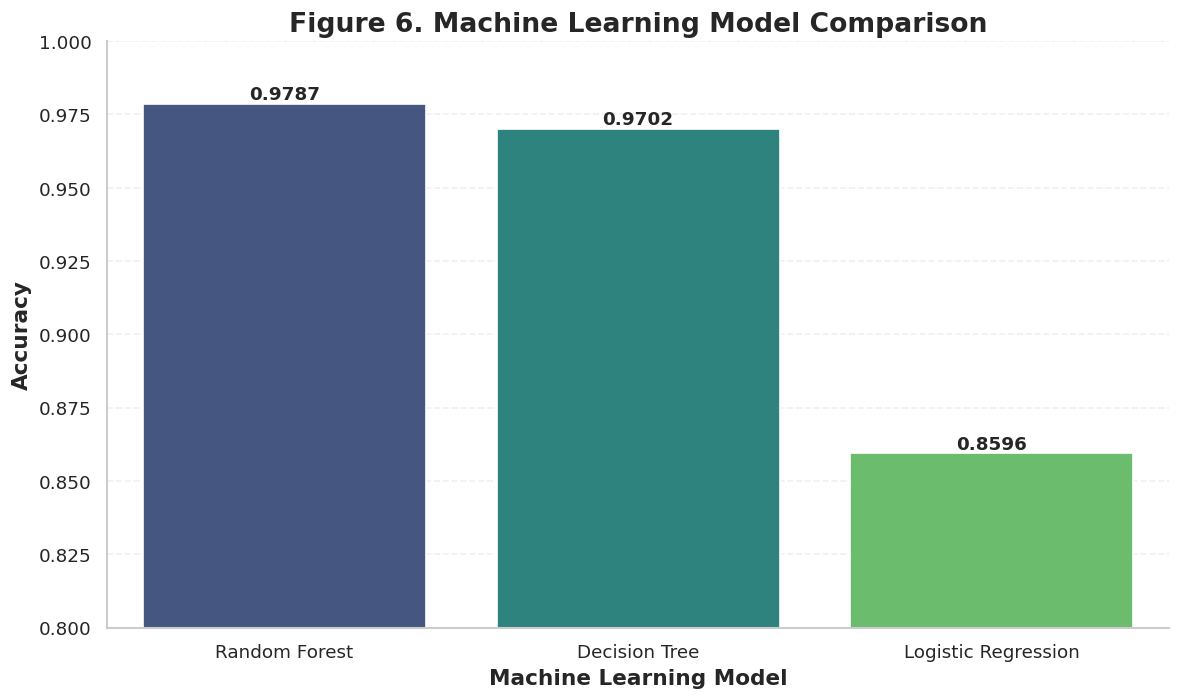

In [ ]:
# ==========================================================
# Figure 6 - Model Performance Comparison
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    hue="Model",          # avoids future seaborn warning
    palette="viridis",
    legend=False
)

# Value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Figure 6. Machine Learning Model Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0.80,1.00)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_PATH,
        "fig06_model_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

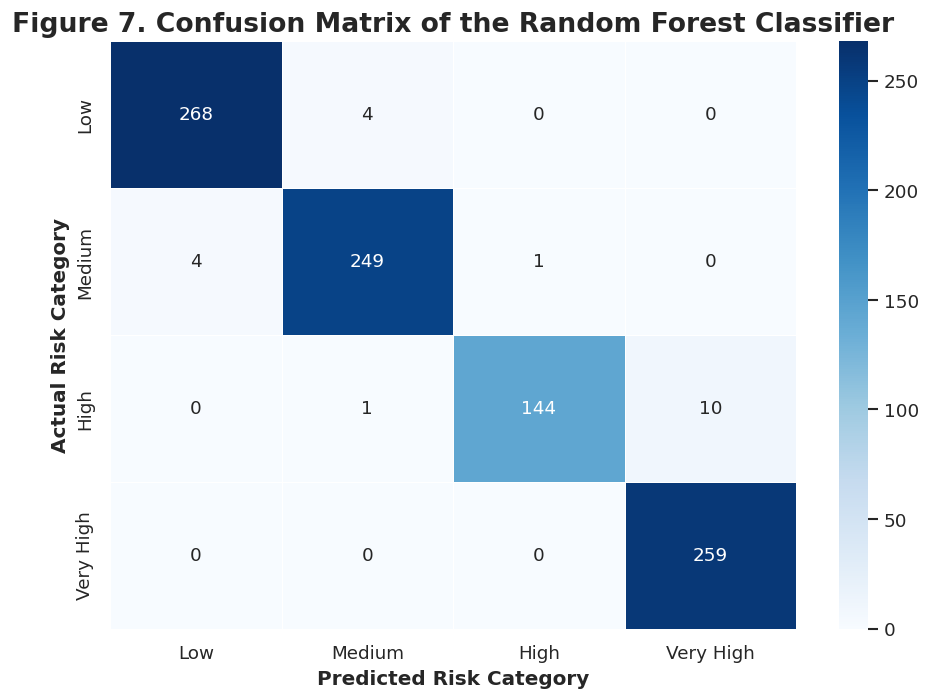

✅ Figure saved successfully.


In [ ]:
# ==========================================================
# Figure 7 - Random Forest Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark predictions to Pandas
rf_results = rf_predictions.select(
    "label",
    "prediction"
).toPandas()

# Compute Confusion Matrix
cm = confusion_matrix(
    rf_results["label"],
    rf_results["prediction"]
)

labels = [
    "Low",
    "Medium",
    "High",
    "Very High"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"fontsize":11}
)

plt.title(
    "Figure 7. Confusion Matrix of the Random Forest Classifier",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Risk Category", fontsize=12)
plt.ylabel("Actual Risk Category", fontsize=12)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_PATH,
        "fig07_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Figure saved successfully.")

### Interpretation

The confusion matrix evaluates the classification performance of the Random Forest model across the four disaster risk categories.

The majority of observations are concentrated along the main diagonal, indicating that the model correctly classified most countries into their respective disaster risk categories. Only a small number of observations were misclassified, primarily between adjacent risk levels, demonstrating the model's strong predictive capability.

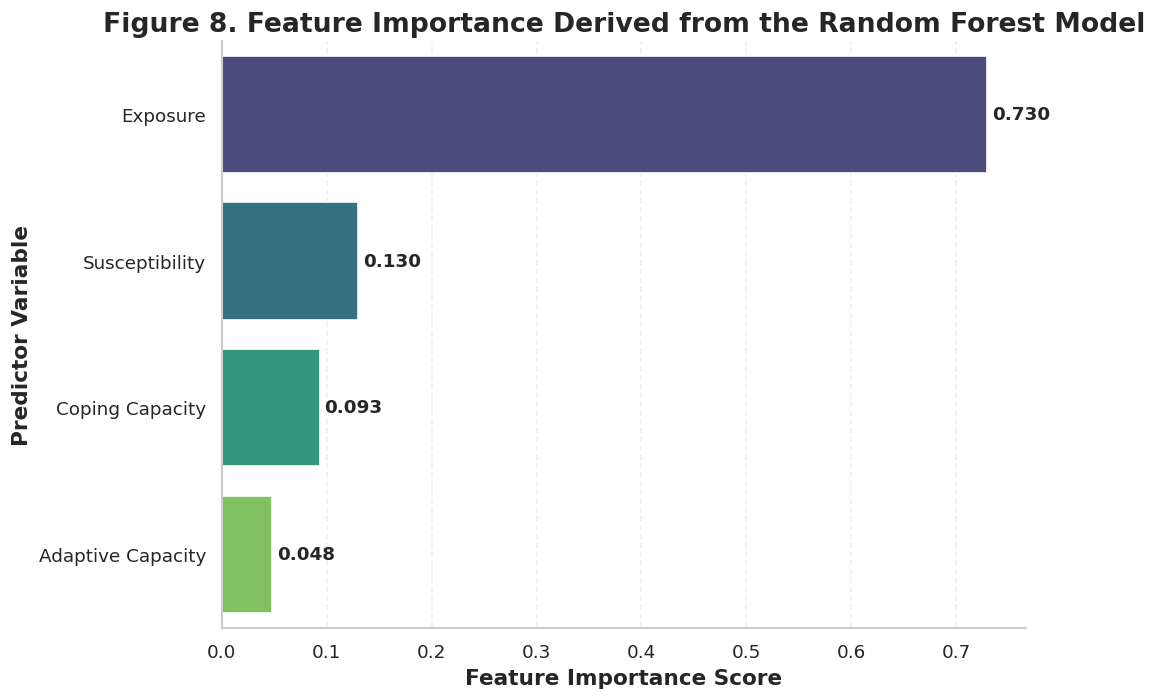

,Feature,Importance
0,Exposure,0.729714
1,Susceptibility,0.129522
2,Coping Capacity,0.093143
3,Adaptive Capacity,0.047621


✅ Figure saved successfully.


In [ ]:
# ==========================================================
# Figure 8 - Random Forest Feature Importance
# ==========================================================

importance_df = pd.DataFrame({
    "Feature": [
        "Exposure",
        "Susceptibility",
        "Coping Capacity",
        "Adaptive Capacity"
    ],
    "Importance": rf_model.featureImportances.toArray()
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Figure 8. Feature Importance Derived from the Random Forest Model",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature Importance Score")
plt.ylabel("Predictor Variable")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_PATH,
        "fig08_feature_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(importance_df)

print("✅ Figure saved successfully.")

### Interpretation

The feature importance analysis identifies the contribution of each predictor variable to the Random Forest classification model.

Exposure was the most influential predictor, indicating that the degree of exposure to hazards plays a dominant role in determining disaster risk categories. Susceptibility, Coping Capacity, and Adaptive Capacity also contributed to the classification process, although their relative importance was lower.

These findings are consistent with the conceptual framework of the World Risk Index, where disaster risk results from the interaction between hazard exposure and societal vulnerability.

#  Conclusion

This study developed a multiclass disaster risk classification model using the World Risk Index dataset and Apache Spark MLlib.

Three supervised learning algorithms—Logistic Regression, Decision Tree, and Random Forest—were evaluated using Accuracy, Precision, Recall, and F1-score.

Among the evaluated models, the Random Forest classifier achieved the highest predictive performance with an accuracy of 97.87%, demonstrating the effectiveness of ensemble learning for disaster risk classification.

Feature importance analysis showed that Exposure was the strongest predictor of disaster risk, followed by Susceptibility, Coping Capacity, and Adaptive Capacity.

The results indicate that machine learning techniques can effectively classify disaster risk levels using the selected World Risk Index indicators and provide valuable support for disaster risk assessment and decision-making.

#  Limitations

- The study used four indicators derived from the World Risk Index dataset.
- The risk categories were generated from WRI score thresholds rather than independently observed disaster outcomes.
- Hyperparameter optimization was not performed.
- Spatial and temporal dependencies were not explicitly modeled.

# References

- World Risk Report
- Apache Spark MLlib Documentation
- PySpark Documentation
- Scikit-learn Documentation
- Python Documentation